=== Data dimensions ===
(1965239, 4)

Columns:
['connectionTime_decimal', 'chargingDuration', 'kWhDelivered', 'dayIndicator']

First 5 rows
   connectionTime_decimal  chargingDuration  kWhDelivered  dayIndicator
0               15.332910          2.301191     11.469551             1
1               16.811495          4.941774      3.611695             1
2               21.151696          3.567173     14.455706             1
3               14.988554          3.089371      5.985330             1
4               15.078276          0.145047      1.274458             1

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1965239 entries, 0 to 1965238
Data columns (total 4 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   connectionTime_decimal  float64
 1   chargingDuration        float64
 2   kWhDelivered            float64
 3   dayIndicator            int64  
dtypes: float64(3), int64(1)
memory usage: 60.0 MB
None

Missing values:
connectionTime

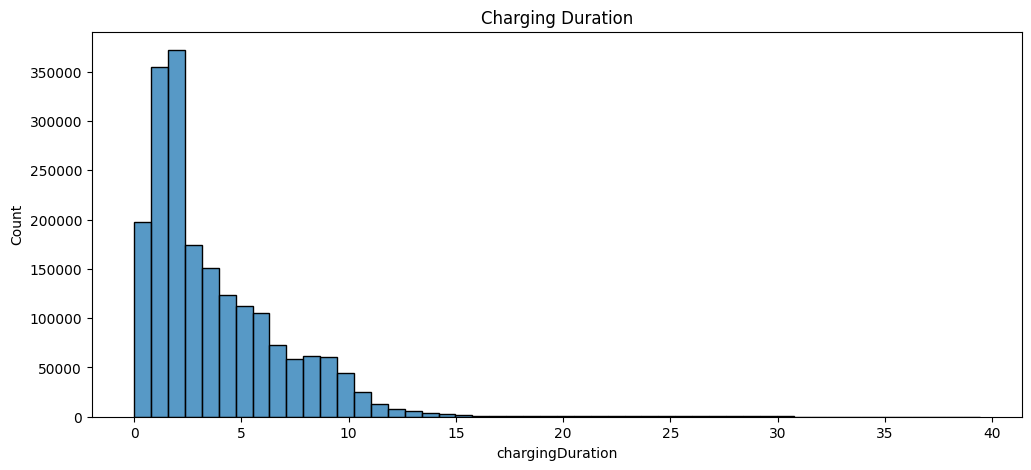

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:\\Users\\ailis\\Downloads\\SYNTHETIC_EV_DATA.csv")  

print("=== Data dimensions ===")
print(df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows")
print(df.head())
print("\nInfo:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

# Απλά plots για να δούμε
plt.figure(figsize=(12,5))
sns.histplot(df['chargingDuration'] if 'chargingDuration' in df.columns else df.iloc[:,1], bins=50)  
plt.title('Charging Duration')
plt.show()

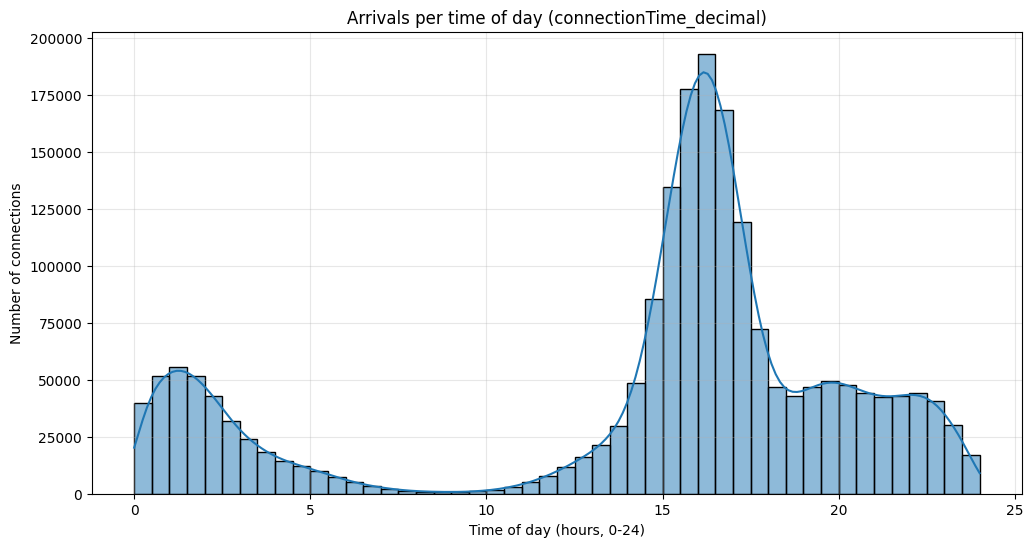

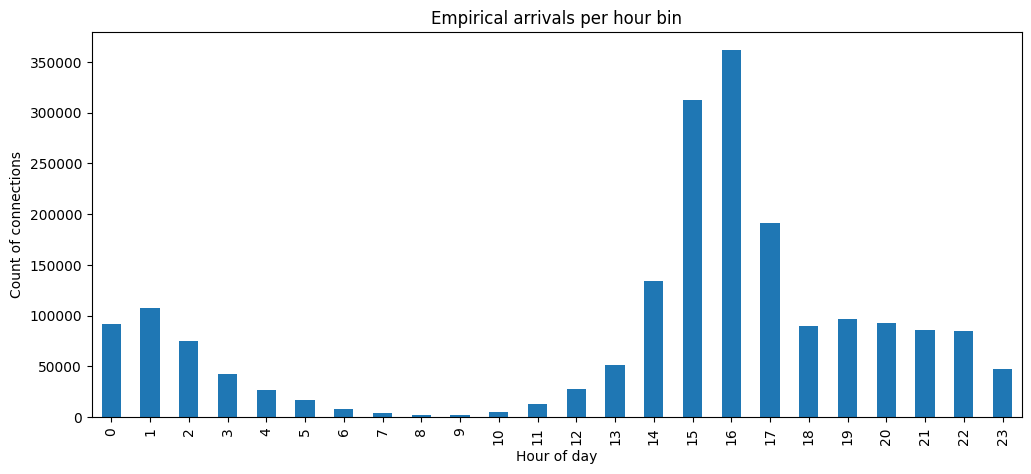


Mean arrivals per hour: 81884.95833333333
Max arrivals : 361352 in hour 16


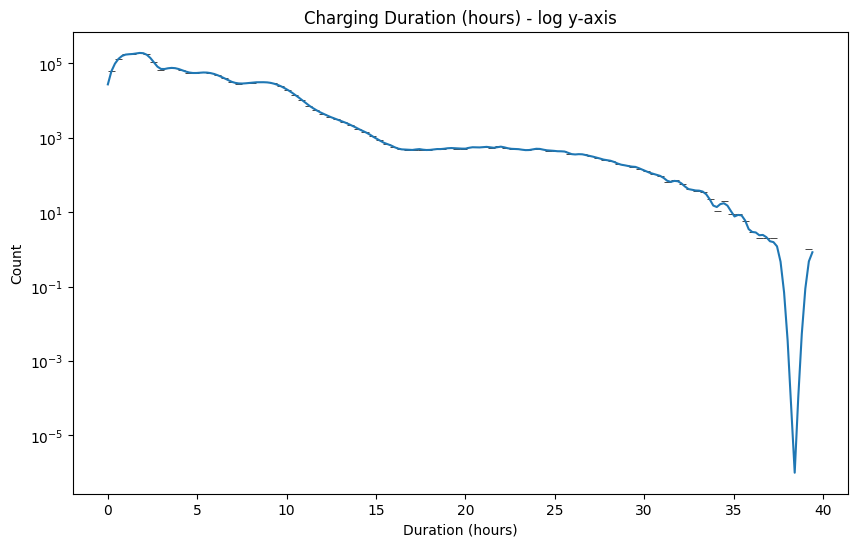


Charging Duration stats:
count    1.965239e+06
mean     3.800781e+00
std      3.387723e+00
min      1.384907e-05
25%      1.443232e+00
50%      2.547029e+00
75%      5.436214e+00
max      3.941106e+01
Name: chargingDuration, dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




# 1. Histogram connectionTime_decimal (arrivals)
plt.figure(figsize=(12, 6))
sns.histplot(df['connectionTime_decimal'], bins=48, kde=True)  # 48 bins = halfhours
plt.title('Arrivals per time of day (connectionTime_decimal)')
plt.xlabel('Time of day (hours, 0-24)')
plt.ylabel('Number of connections')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Empirical arrival rate per hour
df['hour'] = df['connectionTime_decimal'].astype(int)  # 0 to 23
arrivals_per_hour = df['hour'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
arrivals_per_hour.plot(kind='bar')
plt.title('Empirical arrivals per hour bin')
plt.xlabel('Hour of day')
plt.ylabel('Count of connections')
plt.show()

print("\nMean arrivals per hour:", arrivals_per_hour.mean())
print("Max arrivals :", arrivals_per_hour.max(), "in hour", arrivals_per_hour.idxmax())

# 3. Charging duration distribution (log scale for skew)
plt.figure(figsize=(10, 6))
sns.histplot(df['chargingDuration'], bins=100, kde=True, log_scale=(False, True))
plt.title('Charging Duration (hours) - log y-axis')
plt.xlabel('Duration (hours)')
plt.show()

print("\nCharging Duration stats:")
print(df['chargingDuration'].describe())

Μοναδικές ημέρες στο dataset: 29600


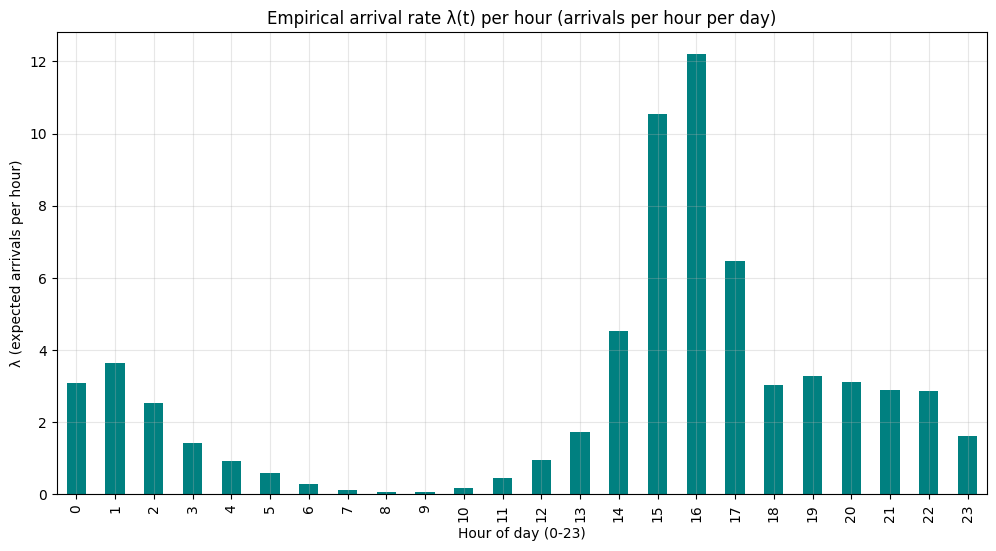


Mean λ (mean per hour): 2.766383727477477
Max λ: 12.207837837837838 at hour 16

lambda_per_hour array (for later):
[ 3.08  3.62  2.53  1.42  0.9   0.58  0.28  0.12  0.06  0.06  0.16  0.44
  0.93  1.72  4.53 10.55 12.21  6.46  3.03  3.26  3.12  2.88  2.86  1.6 ]


In [4]:
# 1. Unique days
n_days = df['dayIndicator'].nunique()
print(f"Μοναδικές ημέρες στο dataset: {n_days}")

# 2. Arrivals per hour (integer)
df['hour'] = df['connectionTime_decimal'].astype(int)  # 0-23

arrivals_per_hour = df['hour'].value_counts().sort_index()

# 3. Empirical λ_h = arrivals / n_days  (rate per hour)
lambda_per_hour = arrivals_per_hour / n_days

plt.figure(figsize=(12, 6))
lambda_per_hour.plot(kind='bar', color='teal')
plt.title('Empirical arrival rate λ(t) per hour (arrivals per hour per day)')
plt.xlabel('Hour of day (0-23)')
plt.ylabel('λ (expected arrivals per hour)')
plt.grid(True, alpha=0.3)
plt.show()

print("\nMean λ (mean per hour):", lambda_per_hour.mean())
print("Max λ:", lambda_per_hour.max(), "at hour", lambda_per_hour.idxmax())
print("\nlambda_per_hour array (for later):")
print(lambda_per_hour.values.round(2))

In [10]:
customers_per_day = df['dayIndicator'].value_counts().sort_index()

print(customers_per_day.describe())          # mean, std, min, max, 25%, 50%, 75%
print("Variance:", customers_per_day.var())
print("Mean:", customers_per_day.mean())
print("\nFirst five dayz:\n", customers_per_day.head())

count    29600.000000
mean        66.393209
std         24.462408
min         17.000000
25%         48.000000
50%         71.000000
75%         86.000000
max        106.000000
Name: count, dtype: float64
Variance: 598.409420423033
Mean: 66.39320945945946

First five dayz:
 dayIndicator
1    43
2    60
3    54
4    57
5    47
Name: count, dtype: int64


In [30]:
mean = customers_per_day.mean()
var = customers_per_day.var()

print(mean, var)

66.39320945945946 598.409420423033


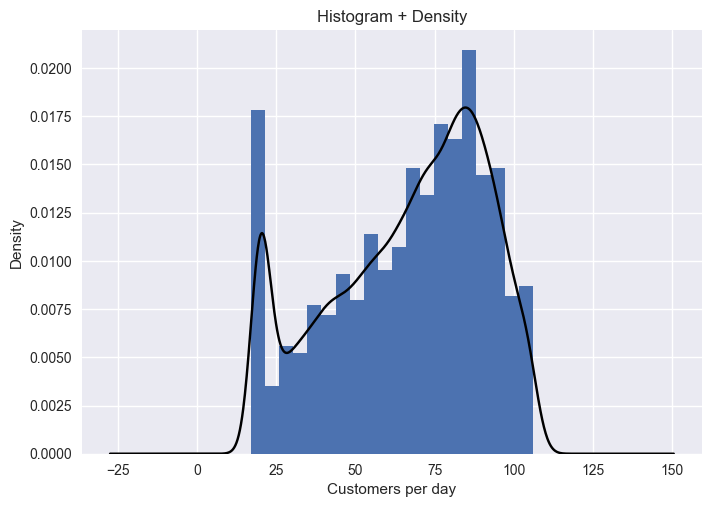

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

customers_per_day = df['dayIndicator'].value_counts().sort_index()

plt.figure()

# Histogram (normalized)
plt.hist(customers_per_day, bins=20, density=True)

# Density curve
customers_per_day.plot(kind='density',color='black')

plt.xlabel('Customers per day')
plt.ylabel('Density')
plt.title('Histogram + Density')

plt.show()

Real kWhDelivered samples available: 1,965,239
Mean = 9.44 kWh, Std = 5.70 kWh
Number of real kWh samples: 1,965,239
Mean   = 9.44 kWh
Std    = 5.70 kWh
Min    = 0.00 kWh
Max    = 62.54 kWh


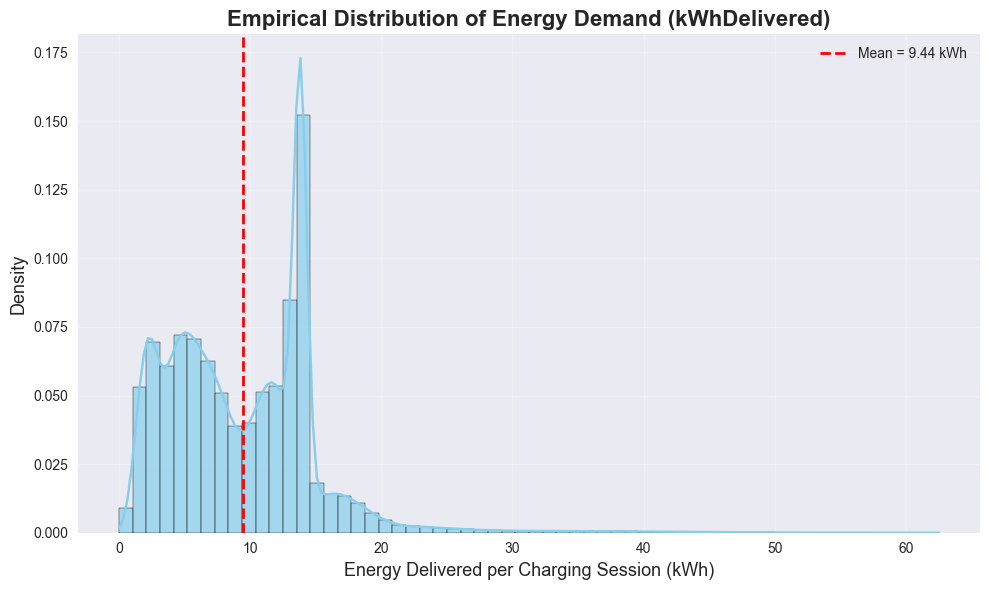

Image saved as 'kwh_distribution.jpg'


In [11]:
# =============================================================================
# SAMPLING ENERGY DEMAND (kWh) FROM EMPIRICAL DISTRIBUTION
# =============================================================================

# Step 1: Extract the real observed kWh values from the dataset
kwh_values = df['kWhDelivered'].dropna().values

# (Optional) Basic statistics for verification
print(f"Real kWhDelivered samples available: {len(kwh_values):,}")
print(f"Mean = {kwh_values.mean():.2f} kWh, Std = {kwh_values.std():.2f} kWh")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------- SETTINGS --------------------------
plt.style.use('seaborn-v0_8')
sns.set_palette("Blues_d")


# -------------------------- EXTRACT kWh VALUES --------------------------
kwh_values = df['kWhDelivered'].dropna().values

print(f"Number of real kWh samples: {len(kwh_values):,}")
print(f"Mean   = {kwh_values.mean():.2f} kWh")
print(f"Std    = {kwh_values.std():.2f} kWh")
print(f"Min    = {kwh_values.min():.2f} kWh")
print(f"Max    = {kwh_values.max():.2f} kWh")

# -------------------------- PLOT EMPIRICAL DISTRIBUTION --------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram + KDE (Kernel Density Estimate)
sns.histplot(kwh_values, bins=60, kde=True, stat="density", 
             color="skyblue", edgecolor="black", alpha=0.7, ax=ax)

# Titles and labels
ax.set_title("Empirical Distribution of Energy Demand (kWhDelivered)", 
             fontsize=16, fontweight='bold')
ax.set_xlabel("Energy Delivered per Charging Session (kWh)", fontsize=13)
ax.set_ylabel("Density", fontsize=13)

# Add mean line
mean_kwh = kwh_values.mean()
ax.axvline(mean_kwh, color='red', linestyle='--', linewidth=2, 
           label=f'Mean = {mean_kwh:.2f} kWh')

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

# -------------------------- SAVE THE IMAGE --------------------------
plt.savefig("kwh_distribution.jpg", dpi=300, bbox_inches='tight')
plt.show()

print("Image saved as 'kwh_distribution.jpg'")

In [14]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture


daily_customers = df.groupby('dayIndicator').size().reset_index(name='num_customers')

# ============================

# ============================
X = daily_customers[['num_customers']].values

gmm = GaussianMixture(n_components=2, random_state=42)
daily_customers['cluster'] = gmm.fit_predict(X)


cluster_means = daily_customers.groupby('cluster')['num_customers'].mean()
low_label = cluster_means.idxmin()  
high_label = cluster_means.idxmax()

daily_customers['type'] = daily_customers['cluster'].map({
    low_label: 'Low-demand',
    high_label: 'High-demand'
})

# ============================
#  ClusteringRES
# ============================
print("=== GMM Clustering Results ===")
print(daily_customers['type'].value_counts(normalize=True).round(4) * 100)
print("\nMean customers per day type:")
print(daily_customers.groupby('type')['num_customers'].mean().round(2))

# ============================
# Βήμα 3:  λ(t) per hour for every cluster
# ============================
if 'hour' not in df.columns:
    df['hour'] = np.floor(df['connectionTime_decimal']).astype(int)


arrivals = df.groupby(['dayIndicator', 'hour']).size().reset_index(name='arrivals')

# Low & High days
low_days = daily_customers[daily_customers['type'] == 'Low-demand']['dayIndicator'].values
high_days = daily_customers[daily_customers['type'] == 'High-demand']['dayIndicator'].values

# λ(t)
lambda_low = (arrivals[arrivals['dayIndicator'].isin(low_days)]
              .groupby('hour')['arrivals']
              .mean()
              .reindex(range(24), fill_value=0)
              .values)

lambda_high = (arrivals[arrivals['dayIndicator'].isin(high_days)]
               .groupby('hour')['arrivals']
               .mean()
               .reindex(range(24), fill_value=0)
               .values)

hours = np.arange(24)
print("\n" + "="*70)
print("Λ(t) per hour(Low-demand days - GMM)")
print("Hour :", hours)
print("λ    :", np.round(lambda_low, 3))

print("\n" + "="*70)
print("Λ(t) per hour(High-demand days - GMM)")
print("Hour :", hours)
print("λ    :", np.round(lambda_high, 3))



=== GMM Clustering Results ===
type
High-demand    64.31
Low-demand     35.69
Name: proportion, dtype: float64

Mean customers per day type:
type
High-demand    82.00
Low-demand     38.27
Name: num_customers, dtype: float64

Λ(t) per hour(Low-demand days - GMM)
Hour : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
λ    : [2.227 2.464 1.991 1.514 1.342 1.231 1.118 1.045 1.006 1.03  1.062 1.155
 1.308 1.616 2.923 6.408 7.548 4.152 2.217 2.273 2.208 2.154 2.152 1.642]

Λ(t) per hour(High-demand days - GMM)
Hour : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
λ    : [ 4.094  4.724  3.433  2.255  1.768  1.49   1.253  1.113  1.058  1.053
  1.122  1.33   1.733  2.487  5.657 12.895 14.815  7.842  3.822  4.148
  4.011  3.782  3.834  2.539]


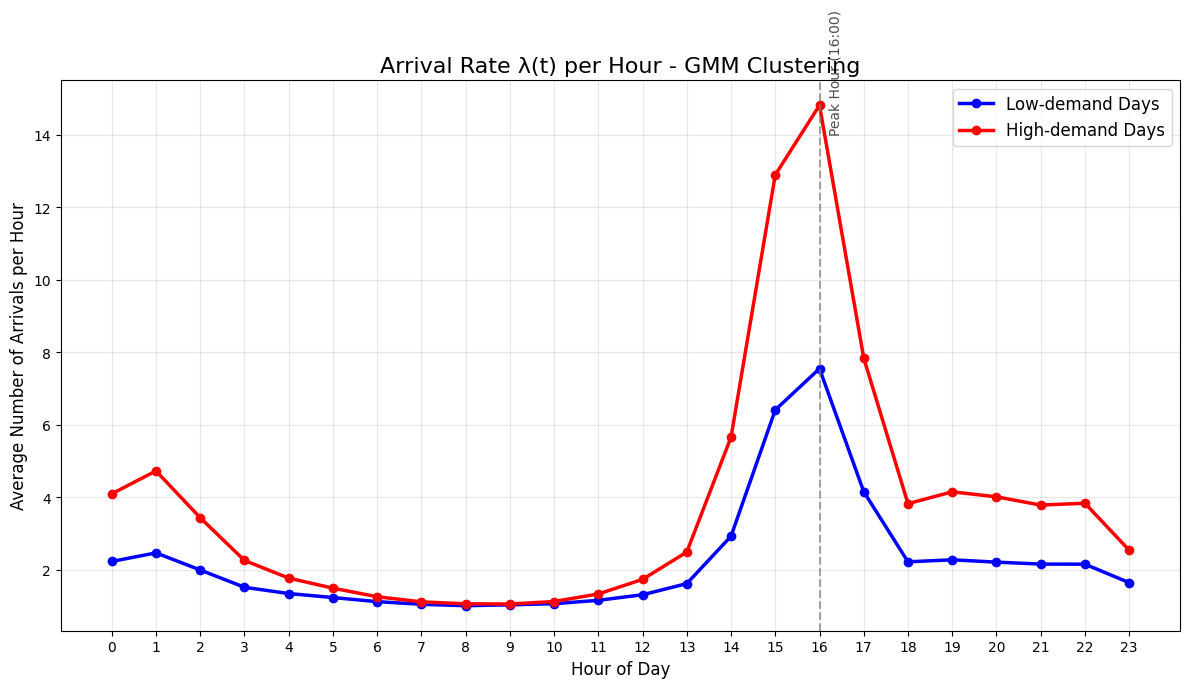

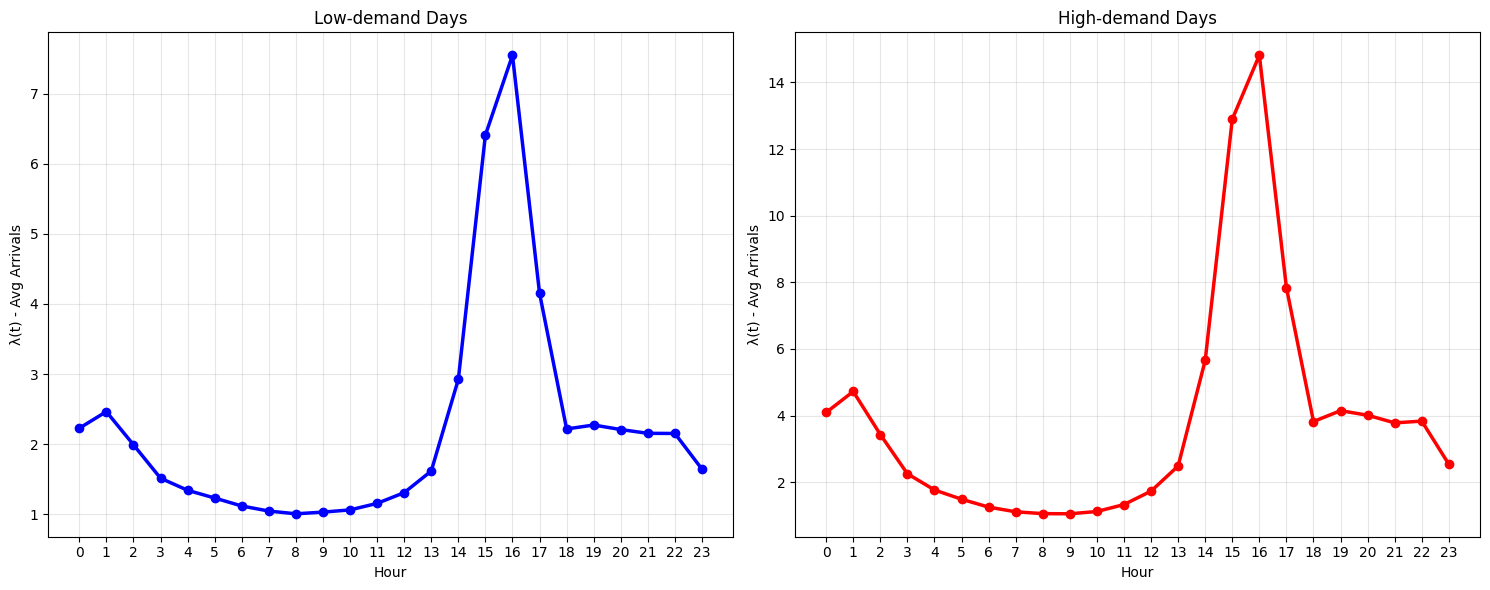

In [15]:
import numpy as np
import matplotlib.pyplot as plt


lambda_low_gmm = np.load('lambda_low_gmm.npy')
lambda_high_gmm = np.load('lambda_high_gmm.npy')

hours = np.arange(24)


plt.figure(figsize=(12, 7))

plt.plot(hours, lambda_low_gmm, marker='o', linestyle='-', linewidth=2.5, 
         color='blue', label='Low-demand Days')

plt.plot(hours, lambda_high_gmm, marker='o', linestyle='-', linewidth=2.5, 
         color='red', label='High-demand Days')

plt.title('Arrival Rate λ(t) per Hour - GMM Clustering', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Number of Arrivals per Hour', fontsize=12)
plt.xticks(hours)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)


plt.axvline(x=16, color='gray', linestyle='--', alpha=0.7)
plt.text(16.2, max(lambda_high_gmm)*0.95, 'Peak Hour (16:00)', rotation=90, alpha=0.7)

plt.tight_layout()
plt.show()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Low Demand
ax1.plot(hours, lambda_low_gmm, marker='o', color='blue', linewidth=2.5)
ax1.set_title('Low-demand Days')
ax1.set_xlabel('Hour')
ax1.set_ylabel('λ(t) - Avg Arrivals')
ax1.set_xticks(hours)
ax1.grid(True, alpha=0.3)

# High Demand
ax2.plot(hours, lambda_high_gmm, marker='o', color='red', linewidth=2.5)
ax2.set_title('High-demand Days')
ax2.set_xlabel('Hour')
ax2.set_ylabel('λ(t) - Avg Arrivals')
ax2.set_xticks(hours)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture

daily_customers = df.groupby('dayIndicator').size().reset_index(name='num_customers')
X = daily_customers[['num_customers']].values

print("=== GMM with different covariance_type ===\n")

for cov_type in ['full', 'diag', 'tied', 'spherical']:
    gmm = GaussianMixture(n_components=2, 
                          covariance_type=cov_type, 
                          random_state=42)
    daily_customers['cluster'] = gmm.fit_predict(X)
    
    cluster_means = daily_customers.groupby('cluster')['num_customers'].mean()
    low_label = cluster_means.idxmin()
    high_label = 1 - low_label
    
    daily_customers['type'] = daily_customers['cluster'].map({low_label: 'Low', high_label: 'High'})
    
    low_pct = (daily_customers['type'] == 'Low').mean() * 100
    high_pct = (daily_customers['type'] == 'High').mean() * 100
    
    print(f"covariance_type = '{cov_type}' → Low: {low_pct:.2f}% | High: {high_pct:.2f}%")

=== GMM with different covariance_type ===

covariance_type = 'full' → Low: 35.69% | High: 64.31%
covariance_type = 'diag' → Low: 35.69% | High: 64.31%
covariance_type = 'tied' → Low: 32.60% | High: 67.40%
covariance_type = 'spherical' → Low: 35.69% | High: 64.31%


In [16]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt



daily_customers = df.groupby('dayIndicator').size().reset_index(name='num_customers')

X = daily_customers[['num_customers']].values


kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
daily_customers['cluster_kmeans'] = kmeans.fit_predict(X)


cluster_means = daily_customers.groupby('cluster_kmeans')['num_customers'].mean()
low_label = cluster_means.idxmin()
high_label = 1 - low_label

daily_customers['type_kmeans'] = daily_customers['cluster_kmeans'].map({
    low_label: 'Low-demand',
    high_label: 'High-demand'
})


print("=== KMeans Clustering Results ===")
print(daily_customers['type_kmeans'].value_counts(normalize=True).round(4) * 100)

print("\nMean number of customers per day (KMeans):")
print(daily_customers.groupby('type_kmeans')['num_customers'].mean().round(2))

print("\nPercentage of customers from high days High-demand μέρες (KMeans):")
total = daily_customers['num_customers'].sum()
high_customers = daily_customers[daily_customers['type_kmeans'] == 'High-demand']['num_customers'].sum()
print(f"{high_customers / total * 100:.1f}%")


print("\n" + "="*60)
print("Comparing different results from CLUSTERING")
print("="*60)

comparison = pd.DataFrame({
    'Method': ['Hard Threshold (66)', 'GMM', 'KMeans'],
    'Low-demand %': [42.72, 35.69, None],
    'High-demand %': [57.28, 64.31, None],
    'Mean Low': [42.27, 38.27, None],
    'Mean High': [84.78, 82.00, None]
})

# Συμπλήρωση KMeans
comparison.loc[comparison['Method'] == 'KMeans', 'Low-demand %'] = \
    (daily_customers['type_kmeans'] == 'Low-demand').mean() * 100
comparison.loc[comparison['Method'] == 'KMeans', 'High-demand %'] = \
    (daily_customers['type_kmeans'] == 'High-demand').mean() * 100
comparison.loc[comparison['Method'] == 'KMeans', 'Mean Low'] = \
    daily_customers[daily_customers['type_kmeans'] == 'Low-demand']['num_customers'].mean()
comparison.loc[comparison['Method'] == 'KMeans', 'Mean High'] = \
    daily_customers[daily_customers['type_kmeans'] == 'High-demand']['num_customers'].mean()

print(comparison.round(2))

=== KMeans Clustering Results ===
type_kmeans
High-demand    63.12
Low-demand     36.88
Name: proportion, dtype: float64

Mean number of customers per day (KMeans):
type_kmeans
High-demand    82.41
Low-demand     38.97
Name: num_customers, dtype: float64

Percentage of customers from high days High-demand μέρες (KMeans):
78.4%

Comparing different results from CLUSTERING
                Method  Low-demand %  High-demand %  Mean Low  Mean High
0  Hard Threshold (66)         42.72          57.28     42.27      84.78
1                  GMM         35.69          64.31     38.27      82.00
2               KMeans         36.88          63.12     38.97      82.41


=== GMM Clustering ===
type
High-demand    64.31
Low-demand     35.69
Name: proportion, dtype: float64

=== Statistics Charging Duration (hours) ===
Low-demand days:
count    404257.000
mean          3.928
std           3.414
min           0.000
25%           1.511
50%           2.742
75%           5.619
max          37.407
Name: chargingDuration, dtype: float64

High-demand days:
count    1560982.000
mean           3.768
std            3.380
min            0.000
25%            1.426
50%            2.507
75%            5.387
max           39.411
Name: chargingDuration, dtype: float64


C:\Users\ailis\AppData\Local\Temp\ipykernel_45068\226638079.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='chargingDuration', data=pd.concat([


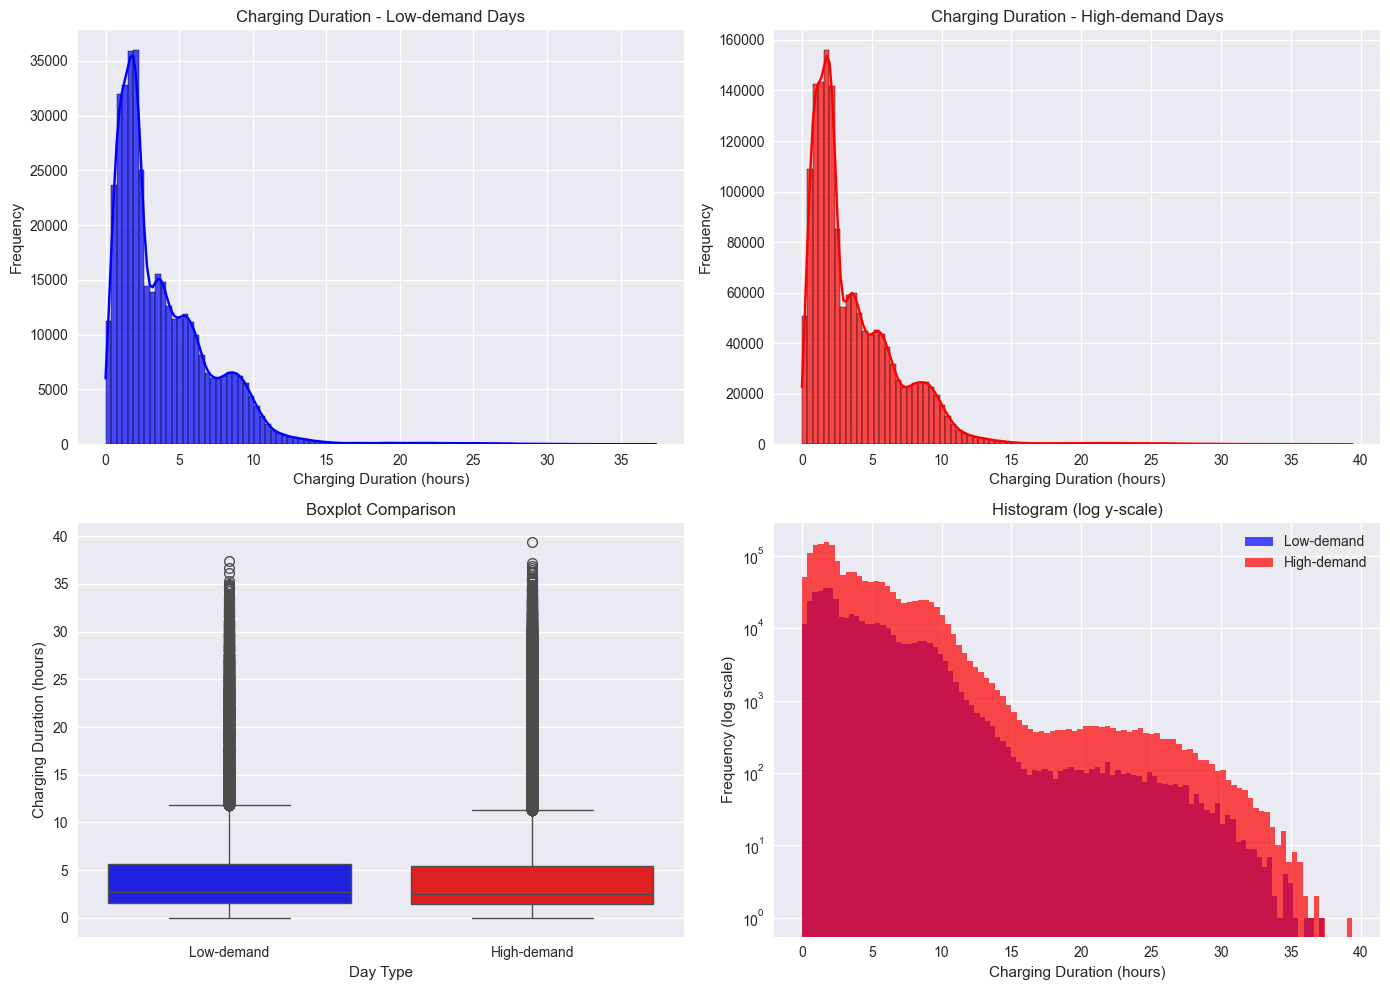

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture


daily_customers = df.groupby('dayIndicator').size().reset_index(name='num_customers')
X = daily_customers[['num_customers']].values

gmm = GaussianMixture(n_components=2, random_state=42)
daily_customers['cluster'] = gmm.fit_predict(X)

means = daily_customers.groupby('cluster')['num_customers'].mean()
low_label = means.idxmin()
high_label = 1 - low_label

daily_customers['type'] = daily_customers['cluster'].map({
    low_label: 'Low-demand',
    high_label: 'High-demand'
})

print("=== GMM Clustering ===")
print(daily_customers['type'].value_counts(normalize=True).round(4)*100)

low_days  = daily_customers[daily_customers['type'] == 'Low-demand']['dayIndicator'].values
high_days = daily_customers[daily_customers['type'] == 'High-demand']['dayIndicator'].values

df_low  = df[df['dayIndicator'].isin(low_days)].copy()
df_high = df[df['dayIndicator'].isin(high_days)].copy()


print("\n=== Statistics Charging Duration (hours) ===")

stats_low = df_low['chargingDuration'].describe().round(3)
stats_high = df_high['chargingDuration'].describe().round(3)

print("Low-demand days:")
print(stats_low)
print("\nHigh-demand days:")
print(stats_high)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram Low
sns.histplot(df_low['chargingDuration'], bins=100, kde=True, ax=axes[0,0], color='blue', alpha=0.7)
axes[0,0].set_title('Charging Duration - Low-demand Days')
axes[0,0].set_xlabel('Charging Duration (hours)')
axes[0,0].set_ylabel('Frequency')

# Histogram High
sns.histplot(df_high['chargingDuration'], bins=100, kde=True, ax=axes[0,1], color='red', alpha=0.7)
axes[0,1].set_title('Charging Duration - High-demand Days')
axes[0,1].set_xlabel('Charging Duration (hours)')
axes[0,1].set_ylabel('Frequency')

# Boxplot 
sns.boxplot(x='type', y='chargingDuration', data=pd.concat([
    df_low.assign(type='Low-demand'),
    df_high.assign(type='High-demand')
]), ax=axes[1,0], palette=['blue', 'red'])
axes[1,0].set_title('Boxplot Comparison')
axes[1,0].set_xlabel('Day Type')
axes[1,0].set_ylabel('Charging Duration (hours)')


axes[1,1].hist(df_low['chargingDuration'], bins=100, alpha=0.7, label='Low-demand', color='blue', log=True)
axes[1,1].hist(df_high['chargingDuration'], bins=100, alpha=0.7, label='High-demand', color='red', log=True)
axes[1,1].set_title('Histogram (log y-scale)')
axes[1,1].set_xlabel('Charging Duration (hours)')
axes[1,1].set_ylabel('Frequency (log scale)')
axes[1,1].legend()

plt.tight_layout()
plt.show()

=== Lognormal Fit  ===
Shape (σ)     : 0.9629
Scale (exp(μ)): 2.5753
Mean          : 4.094 hours
Median        : 2.575 hours


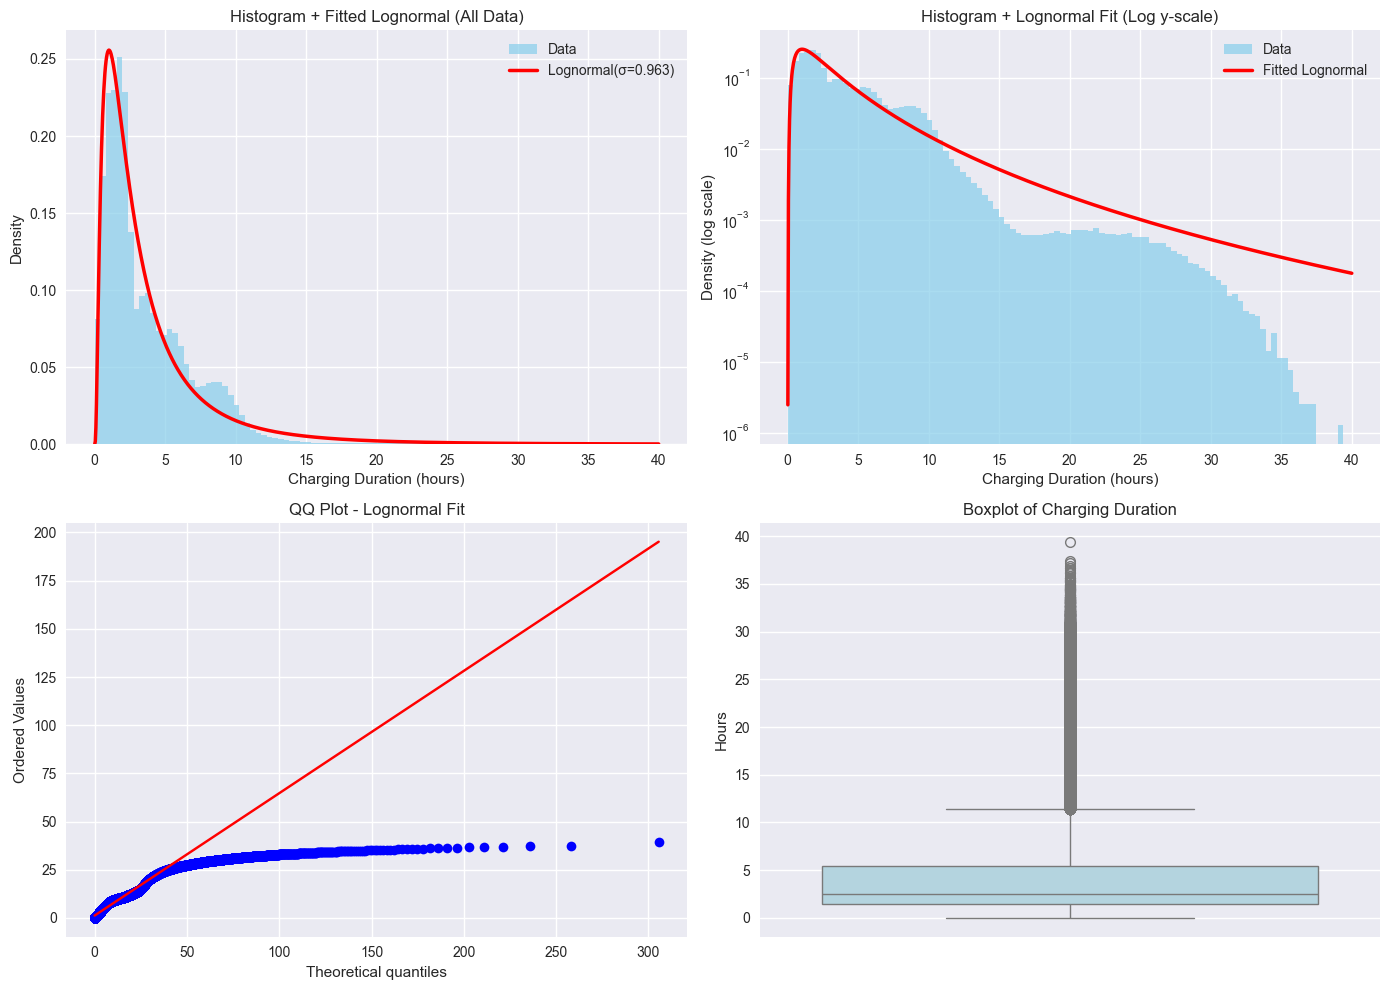


=== Real vs Lognormal ===
Real Mean     : 3.801 hours
Lognorm Mean  : 4.094 hours
Real Median   : 2.547 hours
Lognorm Median: 2.575 hours
Real Std      : 3.388 hours


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import lognorm


data = df['chargingDuration'].dropna().values
data = data[(data > 0) & (data < 48)]

# Fit Lognormal
shape, loc, scale = lognorm.fit(data, floc=0)   # floc=0 consistency

# Στατιστικά
mean_lognorm = lognorm.mean(shape, loc=loc, scale=scale)
median_lognorm = lognorm.median(shape, loc=loc, scale=scale)

print("=== Lognormal Fit  ===")
print(f"Shape (σ)     : {shape:.4f}")
print(f"Scale (exp(μ)): {scale:.4f}")
print(f"Mean          : {mean_lognorm:.3f} hours")
print(f"Median        : {median_lognorm:.3f} hours")


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x = np.linspace(0.01, 40, 1000)
pdf = lognorm.pdf(x, shape, loc=loc, scale=scale)

# Histogram + Fitted Lognormal
axes[0,0].hist(data, bins=100, density=True, alpha=0.7, color='skyblue', label='Data')
axes[0,0].plot(x, pdf, 'r-', lw=2.5, label=f'Lognormal(σ={shape:.3f})')
axes[0,0].set_title('Histogram + Fitted Lognormal (All Data)')
axes[0,0].set_xlabel('Charging Duration (hours)')
axes[0,0].set_ylabel('Density')
axes[0,0].legend()

# Log y-scale
axes[0,1].hist(data, bins=100, density=True, alpha=0.7, color='skyblue', label='Data')
axes[0,1].plot(x, pdf, 'r-', lw=2.5, label='Fitted Lognormal')
axes[0,1].set_title('Histogram + Lognormal Fit (Log y-scale)')
axes[0,1].set_xlabel('Charging Duration (hours)')
axes[0,1].set_ylabel('Density (log scale)')
axes[0,1].set_yscale('log')
axes[0,1].legend()

# QQ Plot
from scipy.stats import probplot
probplot(data, dist=lognorm, sparams=(shape, 0, scale), plot=axes[1,0])
axes[1,0].set_title('QQ Plot - Lognormal Fit')

# Boxplot
sns.boxplot(y=data, ax=axes[1,1], color='lightblue')
axes[1,1].set_title('Boxplot of Charging Duration')
axes[1,1].set_ylabel('Hours')

plt.tight_layout()
plt.show()

# ============================
# 3. Στατιστικά Σύγκριση
# ============================
print("\n=== Real vs Lognormal ===")
print(f"Real Mean     : {data.mean():.3f} hours")
print(f"Lognorm Mean  : {mean_lognorm:.3f} hours")
print(f"Real Median   : {np.median(data):.3f} hours")
print(f"Lognorm Median: {median_lognorm:.3f} hours")
print(f"Real Std      : {data.std():.3f} hours")

=== 2-Component Lognormal Mixture ===

Component 1:
Weight        : 0.596
mu (log)      : 0.497
sigma (log)   : 0.910

Component 2:
Weight        : 0.404
mu (log)      : 1.609
sigma (log)   : 0.580


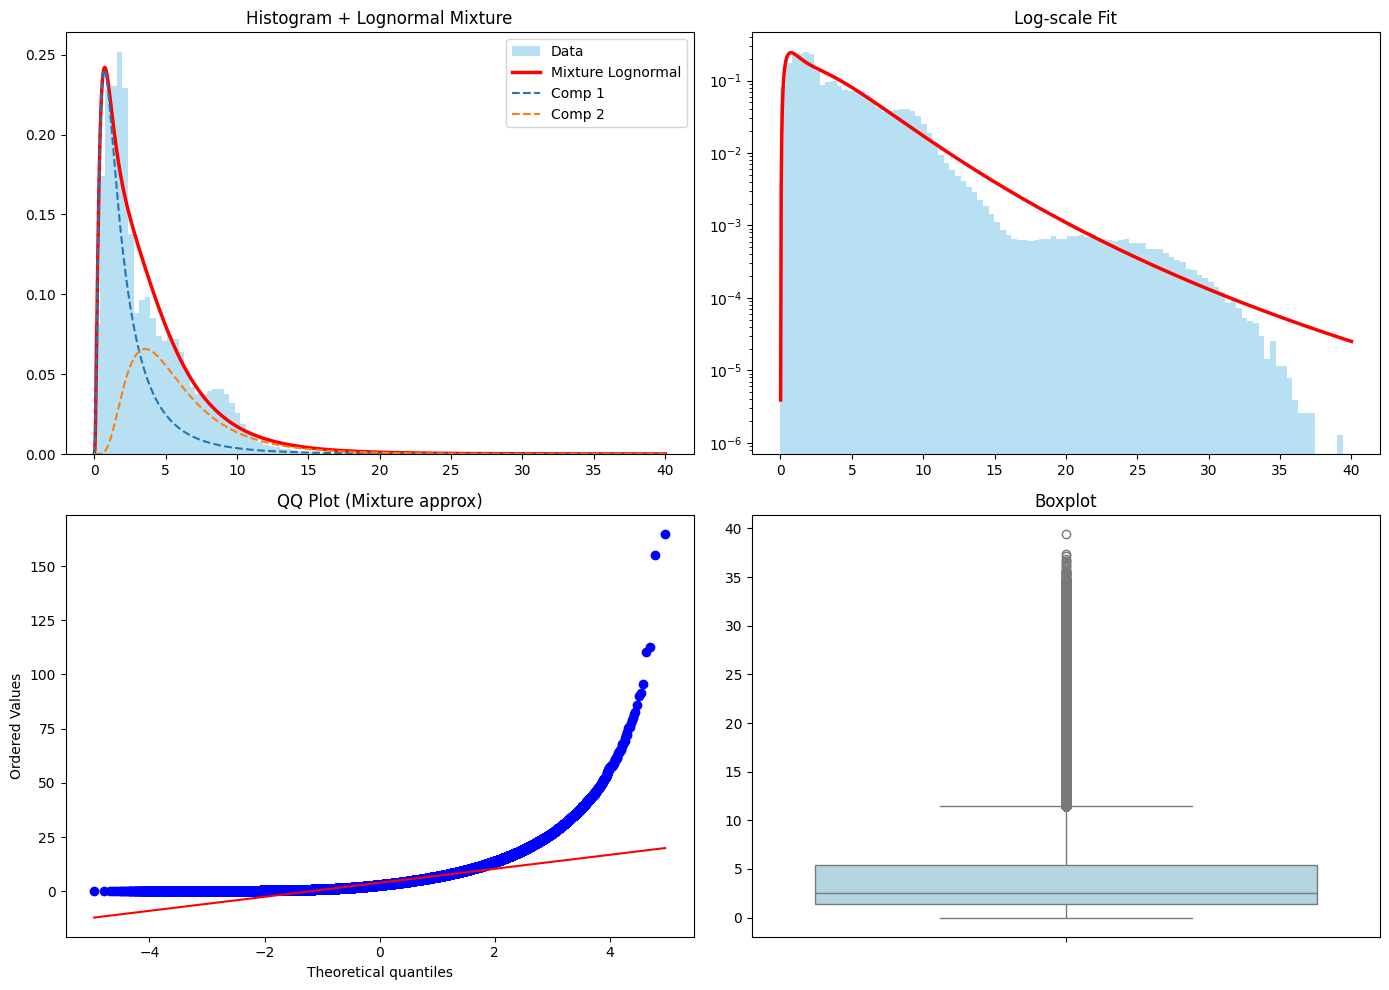

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from scipy.stats import lognorm, probplot

# ============================
# 1. Data prep
# ============================
data = df['chargingDuration'].dropna().values
data = data[(data > 0) & (data < 48)]

log_data = np.log(data).reshape(-1, 1)

# ============================
# 2. Fit 2-component mixture (στο log-space)
# ============================
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(log_data)

weights = gmm.weights_
means = gmm.means_.flatten()
stds = np.sqrt(gmm.covariances_.flatten())

print("=== 2-Component Lognormal Mixture ===")
for i in range(2):
    print(f"\nComponent {i+1}:")
    print(f"Weight        : {weights[i]:.3f}")
    print(f"mu (log)      : {means[i]:.3f}")
    print(f"sigma (log)   : {stds[i]:.3f}")

# ============================
# 3. PDF mixture
# ============================
x = np.linspace(0.01, 40, 1000)

pdf_mix = np.zeros_like(x)
for w, mu, sigma in zip(weights, means, stds):
    pdf_mix += w * lognorm.pdf(x, s=sigma, scale=np.exp(mu))

# ============================
# 4. Plot
# ============================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram + mixture
axes[0,0].hist(data, bins=100, density=True, alpha=0.6, color='skyblue', label='Data')
axes[0,0].plot(x, pdf_mix, 'r-', lw=2.5, label='Mixture Lognormal')

# individual components
for i, (w, mu, sigma) in enumerate(zip(weights, means, stds)):
    axes[0,0].plot(x, w * lognorm.pdf(x, s=sigma, scale=np.exp(mu)),
                   '--', lw=1.5, label=f'Comp {i+1}')

axes[0,0].set_title('Histogram + Lognormal Mixture')
axes[0,0].legend()

# Log-scale
axes[0,1].hist(data, bins=100, density=True, alpha=0.6, color='skyblue')
axes[0,1].plot(x, pdf_mix, 'r-', lw=2.5)
axes[0,1].set_yscale('log')
axes[0,1].set_title('Log-scale Fit')

# QQ plot (approx via sampling from mixture)
samples = []
for w, mu, sigma in zip(weights, means, stds):
    n = int(w * len(data))
    samples.append(np.random.lognormal(mean=mu, sigma=sigma, size=n))
samples = np.concatenate(samples)

probplot(samples, dist="norm", plot=axes[1,0])
axes[1,0].set_title('QQ Plot (Mixture approx)')

# Boxplot
sns.boxplot(y=data, ax=axes[1,1], color='lightblue')
axes[1,1].set_title('Boxplot')

plt.tight_layout()
plt.show()

=== Weibull Fit ===
Shape (k)     : 1.2020
Scale (λ)     : 4.0570
Mean          : 3.815 hours
Median        : 2.991 hours


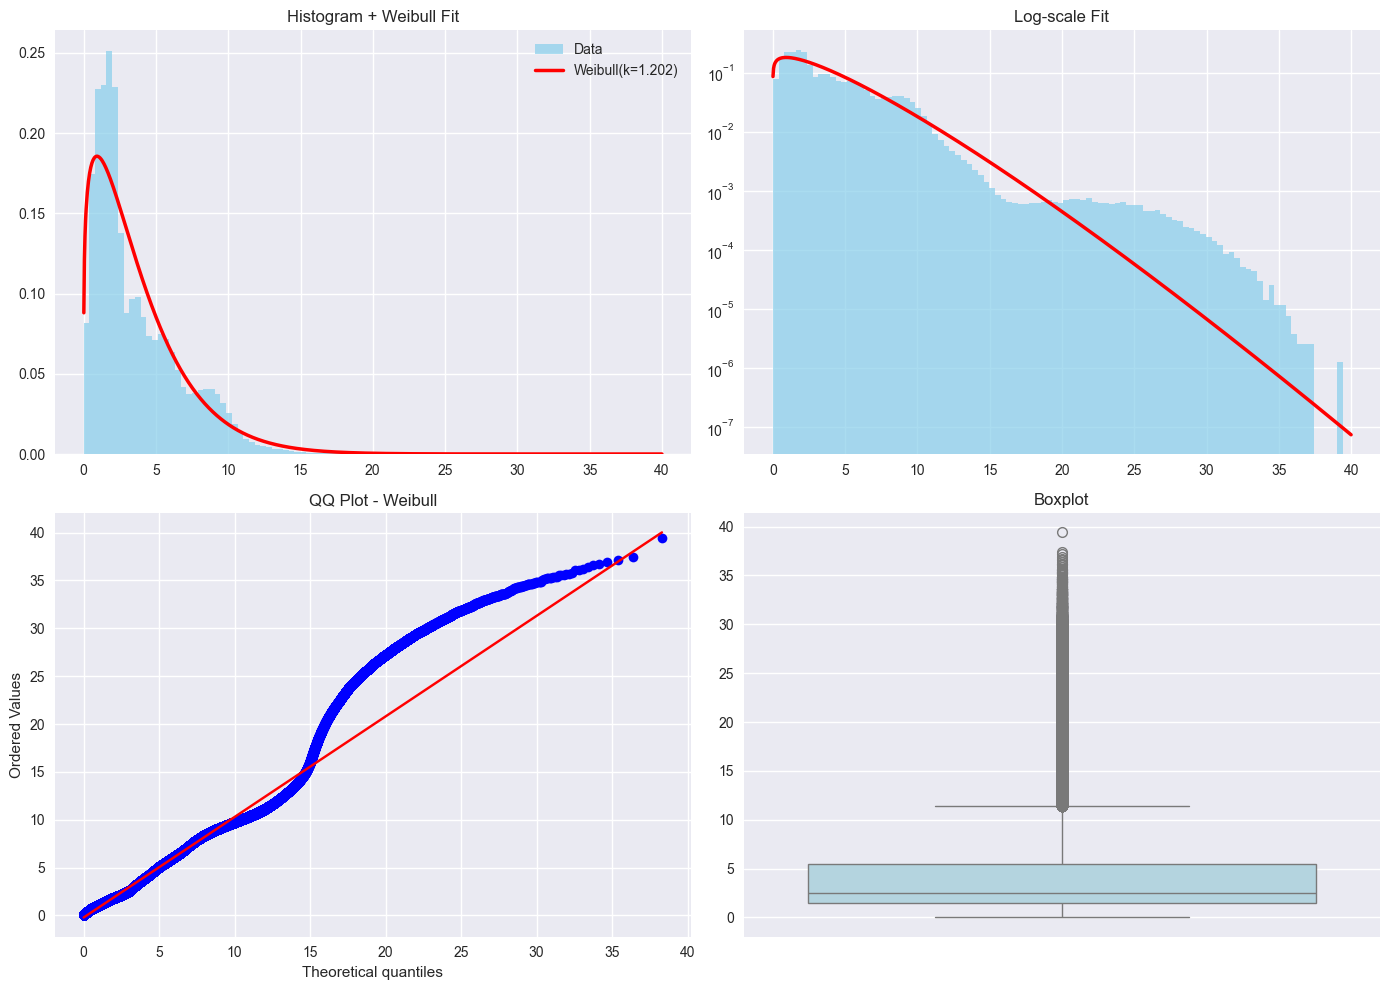


=== Comparison ===
Real Mean     : 3.801
Weibull Mean  : 3.815
Real Median   : 2.547
Weibull Median: 2.991
Real Std      : 3.388


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import weibull_min, probplot

# ============================
# 1. Data prep
# ============================
data = df['chargingDuration'].dropna().values
data = data[(data > 0) & (data < 48)]

# ============================
# 2. Weibull fit
# ============================
shape, loc, scale = weibull_min.fit(data, floc=0)

mean_weibull = weibull_min.mean(shape, loc=loc, scale=scale)
median_weibull = weibull_min.median(shape, loc=loc, scale=scale)

print("=== Weibull Fit ===")
print(f"Shape (k)     : {shape:.4f}")
print(f"Scale (λ)     : {scale:.4f}")
print(f"Mean          : {mean_weibull:.3f} hours")
print(f"Median        : {median_weibull:.3f} hours")

# ============================
# 3. Plot
# ============================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x = np.linspace(0.01, 40, 1000)
pdf = weibull_min.pdf(x, shape, loc=loc, scale=scale)

# Histogram + fit
axes[0,0].hist(data, bins=100, density=True, alpha=0.7, color='skyblue', label='Data')
axes[0,0].plot(x, pdf, 'r-', lw=2.5, label=f'Weibull(k={shape:.3f})')
axes[0,0].set_title('Histogram + Weibull Fit')
axes[0,0].legend()

# Log-scale
axes[0,1].hist(data, bins=100, density=True, alpha=0.7, color='skyblue')
axes[0,1].plot(x, pdf, 'r-', lw=2.5)
axes[0,1].set_yscale('log')
axes[0,1].set_title('Log-scale Fit')

# QQ plot
probplot(data, dist=weibull_min, sparams=(shape, 0, scale), plot=axes[1,0])
axes[1,0].set_title('QQ Plot - Weibull')

# Boxplot
sns.boxplot(y=data, ax=axes[1,1], color='lightblue')
axes[1,1].set_title('Boxplot')

plt.tight_layout()
plt.show()

# ============================
# 4. Σύγκριση
# ============================
print("\n=== Comparison ===")
print(f"Real Mean     : {data.mean():.3f}")
print(f"Weibull Mean  : {mean_weibull:.3f}")
print(f"Real Median   : {np.median(data):.3f}")
print(f"Weibull Median: {median_weibull:.3f}")
print(f"Real Std      : {data.std():.3f}")

=== 2-Weibull Mixture ===
Weight 1 : 0.990
k1, λ1   : 1.263, 3.953
Weight 2 : 0.010
k2, λ2   : 4.900, 24.011


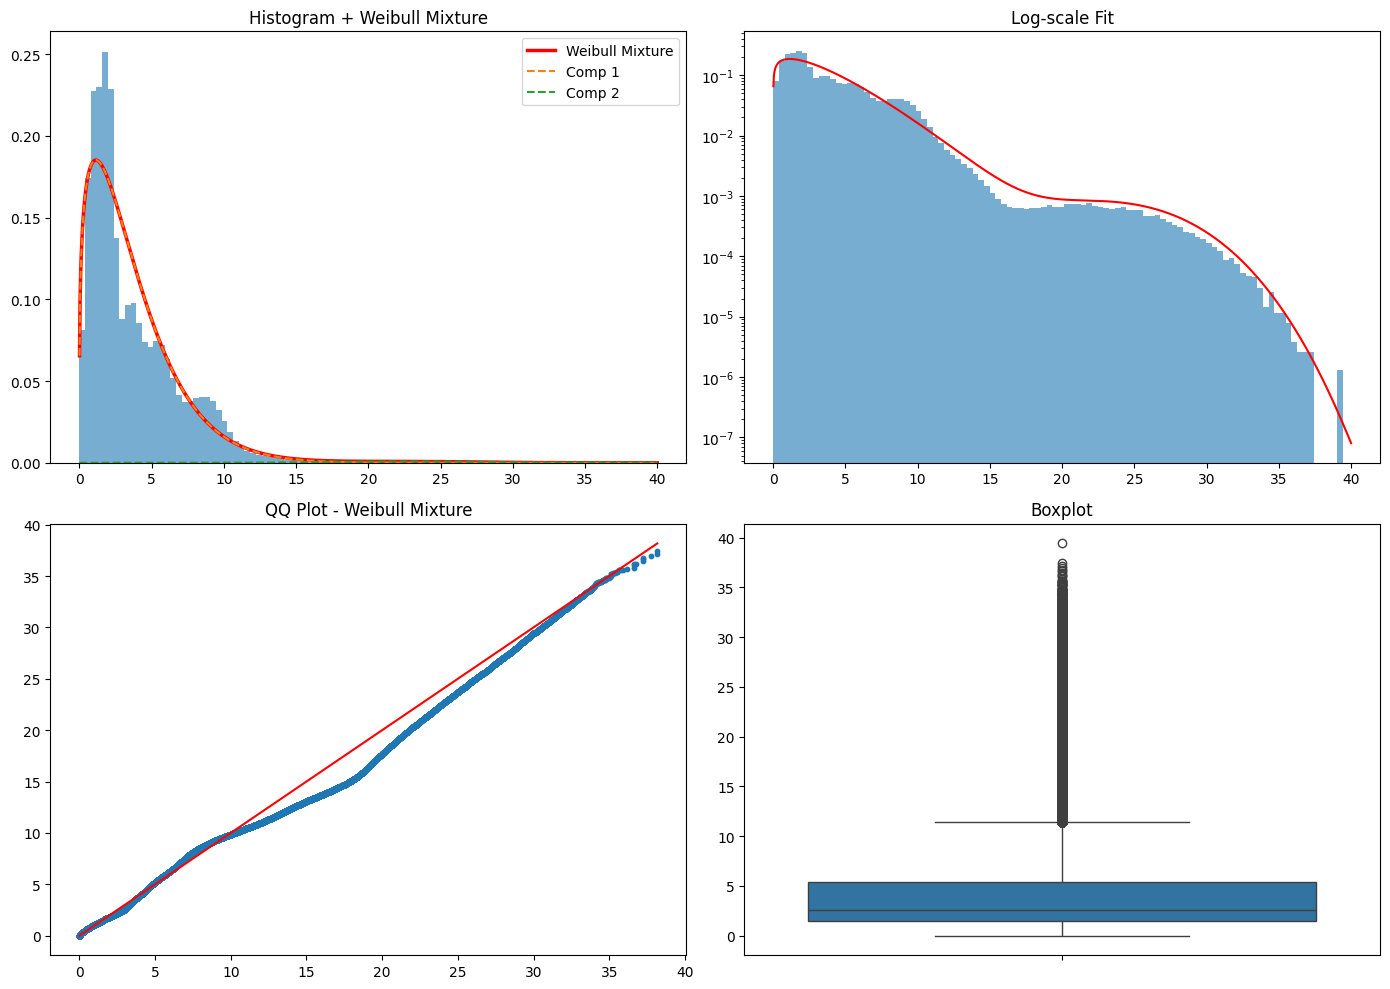

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import weibull_min
from scipy.optimize import minimize

# ============================
# 1. Data
# ============================
data = df['chargingDuration'].dropna().values
data = data[(data > 0) & (data < 48)]

# ============================
# 2. Negative log-likelihood για mixture
# ============================
def neg_log_likelihood(params, x):
    w, k1, l1, k2, l2 = params

    # constraints
    if not (0 < w < 1 and k1 > 0 and l1 > 0 and k2 > 0 and l2 > 0):
        return np.inf

    pdf1 = weibull_min.pdf(x, k1, scale=l1)
    pdf2 = weibull_min.pdf(x, k2, scale=l2)

    mixture_pdf = w * pdf1 + (1 - w) * pdf2

    return -np.sum(np.log(mixture_pdf + 1e-10))  # stability

# ============================
# 3. Initial guess
# ============================
init_params = [0.5, 1.5, 5, 3.0, 15]

# ============================
# 4. Optimization
# ============================
result = minimize(
    neg_log_likelihood,
    init_params,
    args=(data,),
    method='L-BFGS-B',
    bounds=[
        (0.01, 0.99),  # weight
        (0.1, 10),     # k1
        (0.1, 50),     # λ1
        (0.1, 10),     # k2
        (0.1, 50)      # λ2
    ]
)

w, k1, l1, k2, l2 = result.x

print("=== 2-Weibull Mixture ===")
print(f"Weight 1 : {w:.3f}")
print(f"k1, λ1   : {k1:.3f}, {l1:.3f}")
print(f"Weight 2 : {1-w:.3f}")
print(f"k2, λ2   : {k2:.3f}, {l2:.3f}")

# ============================
# 5. PDF
# ============================
x = np.linspace(0.01, 40, 1000)

pdf_mix = (
    w * weibull_min.pdf(x, k1, scale=l1) +
    (1 - w) * weibull_min.pdf(x, k2, scale=l2)
)

# ============================
# 6. Plot
# ============================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0,0].hist(data, bins=100, density=True, alpha=0.6)
axes[0,0].plot(x, pdf_mix, 'r-', lw=2.5, label='Weibull Mixture')

axes[0,0].plot(x, w * weibull_min.pdf(x, k1, scale=l1), '--', label='Comp 1')
axes[0,0].plot(x, (1-w) * weibull_min.pdf(x, k2, scale=l2), '--', label='Comp 2')

axes[0,0].legend()
axes[0,0].set_title('Histogram + Weibull Mixture')

# Log-scale
axes[0,1].hist(data, bins=100, density=True, alpha=0.6)
axes[0,1].plot(x, pdf_mix, 'r-')
axes[0,1].set_yscale('log')
axes[0,1].set_title('Log-scale Fit')

# QQ plot via sampling
samples = np.concatenate([
    weibull_min.rvs(k1, scale=l1, size=int(w*len(data))),
    weibull_min.rvs(k2, scale=l2, size=int((1-w)*len(data)))
])

samples = np.sort(samples)
data_sorted = np.sort(data)

n = min(len(samples), len(data_sorted))

axes[1,0].scatter(samples[:n], data_sorted[:n], s=10)
axes[1,0].plot([0, max(samples)], [0, max(samples)], 'r-')
axes[1,0].set_title('QQ Plot - Weibull Mixture')

# Boxplot
sns.boxplot(y=data, ax=axes[1,1])
axes[1,1].set_title('Boxplot')

plt.tight_layout()
plt.show()

Dataset loaded: 1,965,239 rows, 29600 days
Hours range: 0 - 23

Performing GMM Clustering...
Clustering completed → Low-demand days: 35.7% | High-demand days: 64.3%

Calculating hourly arrival statistics...

LOW DEMAND DAYS - Hourly Statistics
    hour   mean    std  count  min  max     cv  poisson_cv
0      0  2.227  1.419   7835    1   11  0.637       0.670
1      1  2.464  1.580   8312    1   13  0.641       0.637
2      2  1.991  1.214   7372    1   11  0.610       0.709
3      3  1.514  0.820   5311    1    7  0.541       0.813
4      4  1.342  0.614   3792    1    5  0.458       0.863
5      5  1.231  0.527   2694    1    5  0.428       0.901
6      6  1.118  0.351   1437    1    3  0.314       0.946
7      7  1.045  0.215    641    1    3  0.206       0.978
8      8  1.006  0.078    324    1    2  0.078       0.997
9      9  1.030  0.171    333    1    2  0.166       0.985
10    10  1.062  0.258    909    1    3  0.243       0.971
11    11  1.155  0.408   2230    1    4  0.354  

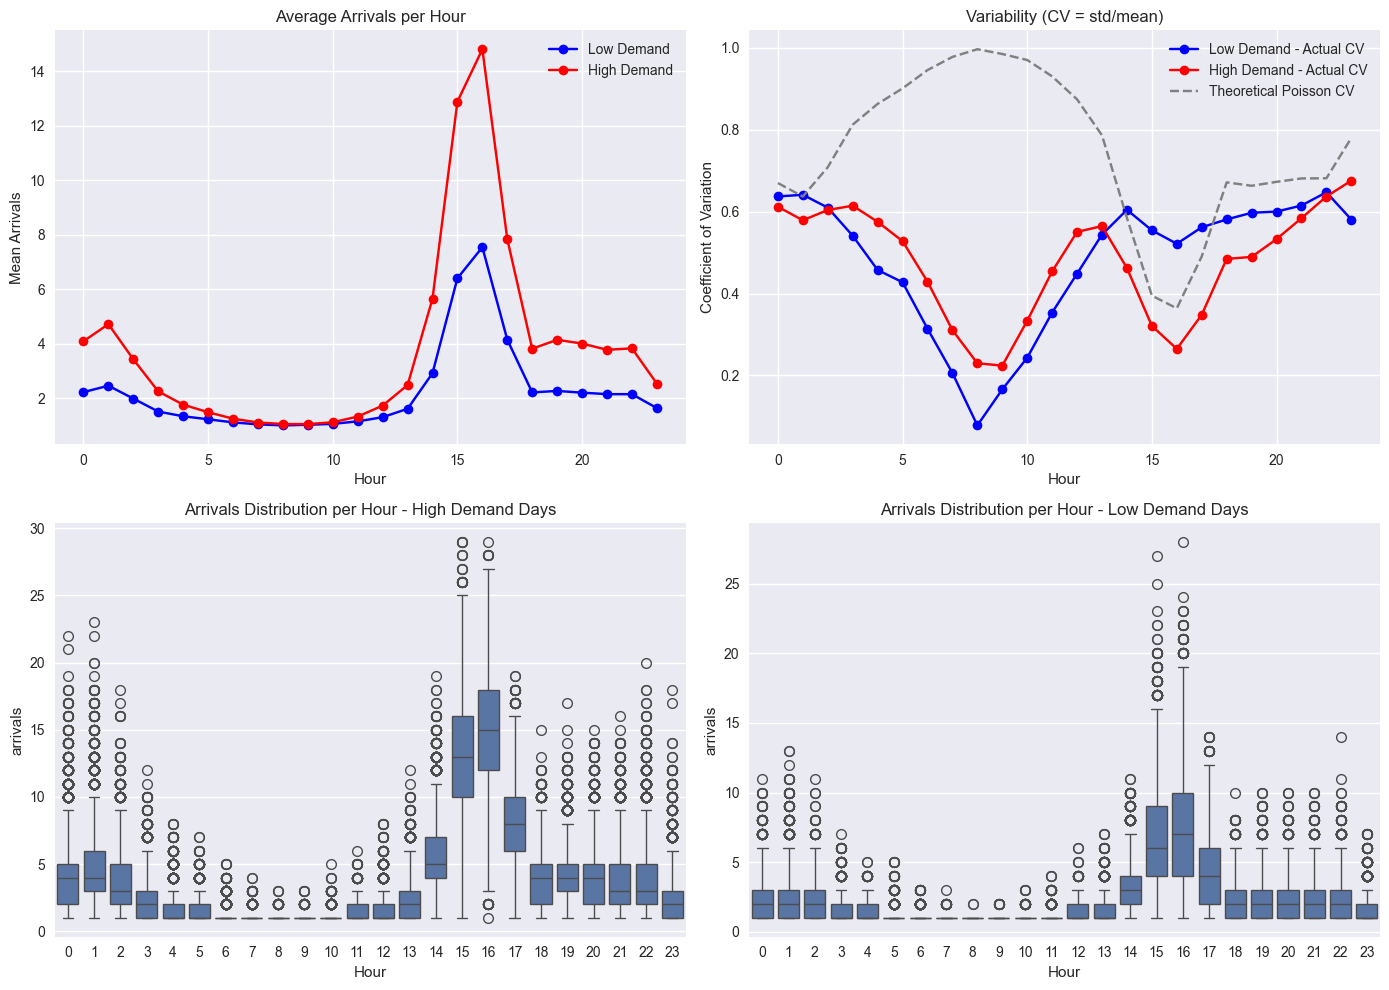


SUMMARY OF VARIABILITY
Max CV (Low) : 0.65  → Acceptable
Max CV (High): 0.68  → Acceptable
✅ Approximation with hourly average is good.


In [21]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture

plt.style.use('seaborn-v0_8')




# Keep only needed columns
df = df[['dayIndicator', 'chargingDuration', 'connectionTime_decimal', 'kWhDelivered']].copy()

# Create hour column
df['hour'] = np.floor(df['connectionTime_decimal']).astype(int)

print(f"Dataset loaded: {df.shape[0]:,} rows, {df['dayIndicator'].nunique()} days")
print(f"Hours range: {df['hour'].min()} - {df['hour'].max()}")

# ====================== 2. GMM CLUSTERING ======================
print("\nPerforming GMM Clustering...")

daily_customers = df.groupby('dayIndicator').size().reset_index(name='num_customers')
X = daily_customers[['num_customers']].values

gmm = GaussianMixture(n_components=2, random_state=42)
daily_customers['cluster'] = gmm.fit_predict(X)

means = daily_customers.groupby('cluster')['num_customers'].mean()
low_label = means.idxmin()
high_label = 1 - low_label

daily_customers['type'] = daily_customers['cluster'].map({low_label: 'Low-demand', high_label: 'High-demand'})

P_LOW = (daily_customers['type'] == 'Low-demand').mean()
P_HIGH = 1 - P_LOW

print(f"Clustering completed → Low-demand days: {P_LOW:.1%} | High-demand days: {P_HIGH:.1%}")

low_days = daily_customers[daily_customers['type'] == 'Low-demand']['dayIndicator'].values
high_days = daily_customers[daily_customers['type'] == 'High-demand']['dayIndicator'].values

# ====================== 3. HOURLY ARRIVAL RATE VALIDATION ======================
print("\nCalculating hourly arrival statistics...")

arrivals_per_hour = df.groupby(['dayIndicator', 'hour']).size().reset_index(name='arrivals')

# Στατιστικά ανά ώρα (Low vs High)
def get_hourly_stats(days):
    data = arrivals_per_hour[arrivals_per_hour['dayIndicator'].isin(days)]
    stats = data.groupby('hour')['arrivals'].agg(['mean', 'std', 'count', 'min', 'max']).reset_index()
    stats['cv'] = stats['std'] / stats['mean']                    # Coefficient of Variation
    stats['poisson_cv'] = 1 / np.sqrt(stats['mean'])              # Theoretical Poisson CV
    return stats

low_stats = get_hourly_stats(low_days)
high_stats = get_hourly_stats(high_days)

# ====================== 4. PRINT RESULTS ======================
print("\n" + "="*60)
print("LOW DEMAND DAYS - Hourly Statistics")
print(low_stats.round(3))

print("\nHIGH DEMAND DAYS - Hourly Statistics")
print(high_stats.round(3))

# ====================== 5. PLOTS ======================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Mean arrivals per hour
axes[0,0].plot(low_stats['hour'], low_stats['mean'], marker='o', label='Low Demand', color='blue')
axes[0,0].plot(high_stats['hour'], high_stats['mean'], marker='o', label='High Demand', color='red')
axes[0,0].set_title("Average Arrivals per Hour")
axes[0,0].set_xlabel("Hour")
axes[0,0].set_ylabel("Mean Arrivals")
axes[0,0].legend()
axes[0,0].grid(True)

# 2. Coefficient of Variation
axes[0,1].plot(low_stats['hour'], low_stats['cv'], marker='o', label='Low Demand - Actual CV', color='blue')
axes[0,1].plot(high_stats['hour'], high_stats['cv'], marker='o', label='High Demand - Actual CV', color='red')
axes[0,1].plot(low_stats['hour'], low_stats['poisson_cv'], '--', label='Theoretical Poisson CV', color='gray')
axes[0,1].set_title("Variability (CV = std/mean)")
axes[0,1].set_xlabel("Hour")
axes[0,1].set_ylabel("Coefficient of Variation")
axes[0,1].legend()
axes[0,1].grid(True)

# 3. Boxplot arrivals per hour (High demand)
sns.boxplot(data=arrivals_per_hour[arrivals_per_hour['dayIndicator'].isin(high_days)], 
            x='hour', y='arrivals', ax=axes[1,0])
axes[1,0].set_title("Arrivals Distribution per Hour - High Demand Days")
axes[1,0].set_xlabel("Hour")

# 4. Boxplot arrivals per hour (Low demand)
sns.boxplot(data=arrivals_per_hour[arrivals_per_hour['dayIndicator'].isin(low_days)], 
            x='hour', y='arrivals', ax=axes[1,1])
axes[1,1].set_title("Arrivals Distribution per Hour - Low Demand Days")
axes[1,1].set_xlabel("Hour")

plt.tight_layout()
plt.show()

# ====================== SUMMARY ======================
print("\n" + "="*60)
print("SUMMARY OF VARIABILITY")
print(f"Max CV (Low) : {low_stats['cv'].max():.2f}  → {'High' if low_stats['cv'].max() > 1.8 else 'Acceptable'}")
print(f"Max CV (High): {high_stats['cv'].max():.2f}  → {'High' if high_stats['cv'].max() > 1.8 else 'Acceptable'}")

if high_stats['cv'].max() > 2.0 or low_stats['cv'].max() > 2.0:
    print("⚠️  Big varinace! Simple hourly λ might might underestimate real variability.")
else:
    print("✅ Approximation with hourly average is good.")